# Does a "counterattack line" actually reverse a downtrend? ⚔️
### A famous candlestick — two opposite-colour candles closing at the same price — meets a stopwatch

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Meeting_forecasts%3F: Busted](https://img.shields.io/badge/Meeting_forecasts%3F-Busted-8b949e?style=flat-square)

Open any candlestick book and you'll find the **counterattack** (or **meeting**) line: in a falling market, a red/black candle drops, then the next candle gaps *lower* on the open but rallies all day to **close at exactly the previous close** — the two closes "meet". The lore, from Steve Nison's candlestick canon, is that this equal-close meeting is where the sellers ran out of ammunition: **buy, the trend is about to flip up.**

It *looks* compelling on a hand-picked chart. But a two-candle pattern read off recent price, on a market (stock indices) that drifts **up** over time, is the textbook setup for fooling yourself. So we did the only fair thing: encode the meeting line **mechanically** (a concrete equal-close tolerance, no eyeballing), fire the buy across five big indices over 21 years, and time the result with a stopwatch — against the only baseline that matters: **buying on random days instead.**

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice** — research & education. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from counterattack_lines import data, strategy as st

ASOF = "2026-05-31"
TOL = st.DEFAULT_TOL
LB = st.DEFAULT_TREND_LOOKBACK
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real meeting-line cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 280, 'tol_bps': 15, 'lookback': 10, 'fp_spy': '4cb5244f3990', 'h5': (5, 280, -7.6, 53, -0.46, 61.0, -68.6, -9.6, -3.01, 0.003), 'h10': (10, 280, 11.5, 55, 0.53, 73.0, -61.5, 9.5, -1.97, 0.049), 'h20': (20, 279, 111.3, 63, 3.5, 97.9, 13.4, 109.3, 0.33, 0.741), 'h60': (60, 278, 264.6, 70, 4.2, 118.0, 146.6, 262.6, 1.99, 0.047), 'per': [('SPY', 51, 41.1, 0.71, 36.7, 4.4), ('QQQ', 53, 193.6, 2.19, 129.9, 63.7), ('IWM', 47, 192.3, 3.03, 51.5, 140.8), ('DIA', 53, 53.5, 0.72, 38.1, 15.4), ('GLD', 76, 90.8, 1.57, 189.4, -98.7)], 'placebo': (41.1, 0.623, 500), 'syn': [(0.0, 68, -34.4, 46, -0.64), (0.6, 50, 595.9, 92, 9.86)]}


real meeting-line cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## The answer first

| Question | Answer |
|---|---|
| If I buy a bullish meeting line, do I make money? | **At 20–60 days, yes — but only because the market goes up.** At the 1–2 week horizon where the "reversal" is supposed to act, the return is roughly **flat or negative**. |
| Is that *the pattern's* doing? | **No.** Buy on **random days** instead and you do **just as well or better** — at 5 days the meeting line is *significantly worse* than a coin-flip entry. |
| Does the *equal close* matter? | **No.** Keep the down-leg-and-gap setup but ignore whether the closes actually meet, and you get the same result. The meeting adds nothing. |
| So is it a tradable edge? | **No.** It's **beta in a costume** — a dip after a down leg, re-labelled as a candlestick reversal. |

> The counterattack line is a tidy way to *name* a candle after the fact. As a *forecast* — "the meeting marks the bottom" — it's a **mirage**: the longer-horizon gains are the market's climb, and the equal close itself does no work.

## 1 · The claim

> *"In a downtrend, a black candle falls. The next candle gaps lower but closes right back at the prior close — the closes **meet**. The bears have been answered: buy, the trend reverses up."*

This is the **bullish counterattack / meeting line** (Japanese *deai sen*), brought West by **Steve Nison** in *Japanese Candlestick Charting Techniques* (1991) and catalogued by Morris and Bulkowski. It's the weaker cousin of the *piercing line* (which must close *above* the prior midpoint); the counterattack only asks the closes to meet — so it's a clean test of: **does an equal close forecast anything?**

## 2 · So what?

If the meeting genuinely *forecast* reversals, it would be remarkable: two candles and a coincidence of closing prices would predict a turn, a crack in market efficiency you could trade off the chart. That's the dream the pattern sells.

But there's a trap built into it. A meeting line is *defined* by a recent down leg, so the rule is a **dip-buy** — and on a market that drifts **up**, *any* dip-buy looks profitable. To separate the **pattern** from the **tide**, we have to (a) detect the meeting by a fixed mechanical rule with no hindsight, and (b) compare it to buying on **random days**, and (c) check whether the *equal close* (not just the dip) is doing anything. We'll do all three.

## 3 · How would we even know?

We take **5 liquid indices/ETFs** (SPY, QQQ, IWM, DIA, GLD), daily, over **21 years** (2005-01-03 → 2026-05-29), and:

1. **Detect the meeting mechanically.** A bullish meeting = a confirmed down leg (close below where it was 10 bars ago), a black candle, then a white candle that gaps down and closes **within 15 bps** of the prior close. No eyeballing.
2. **Trade the lore.** On the meeting bar's close, buy at the **next** close; measure the return over the next **5 / 10 / 20 / 60 days**.
3. **The honest baseline.** Do the exact same hold on **random days**. If the meeting matters, it must beat random. *If it doesn't, the pattern is a mirage* — that's the result that would make us say so, announced before we look.
4. **The geometry check.** Keep the down-leg-and-gap setup but ignore the equal close; if that does just as well, the *meeting* was never the point.

## 4 · The teardown — let's actually look

First, what does a mechanical meeting line even look like? Here's SPY with the bullish meeting signals the rule would buy marked on the tape.

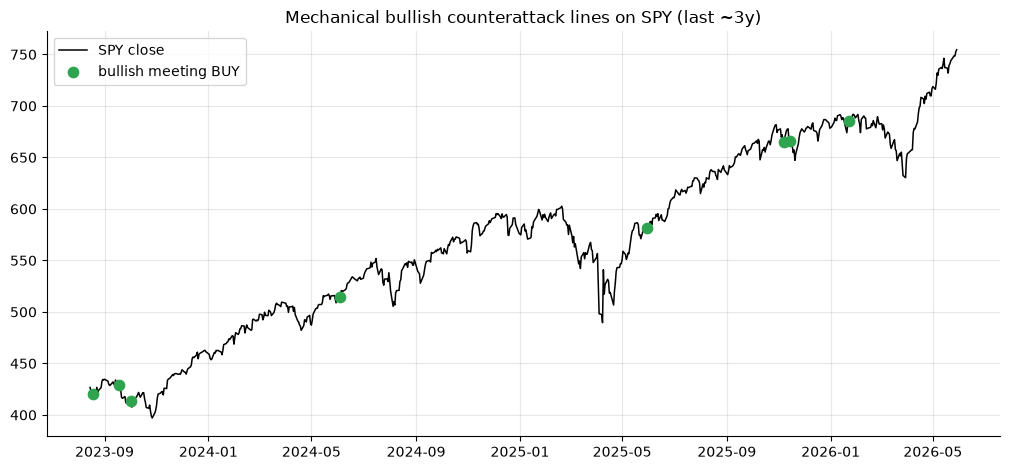

bullish meeting lines in window: 8


In [2]:
b = load('SPY') if HAVE_REAL else None
if HAVE_REAL:
    cl = b['close']; seg = cl.iloc[-700:]
    ent = st.meeting_entries(b, tol=TOL, trend_lookback=LB)
    ent = ent[ent >= seg.index[0]]
    fig, ax = plt.subplots(figsize=(10.2, 4.8))
    ax.plot(seg.index, seg.values, c='k', lw=1.1, label='SPY close')
    ax.scatter(ent, cl.reindex(ent), c=GREEN, s=55, zorder=5, label='bullish meeting BUY')
    ax.set_title('Mechanical bullish counterattack lines on SPY (last ~3y)'); ax.legend(loc='upper left')
    plt.tight_layout(); plt.show()
    print('bullish meeting lines in window:', len(ent))
else:
    print('(no cache — see docs/results.md for the frozen numbers)')

The signals cluster around dips — exactly as a dip-buy would. The question is whether those green buy dots are followed by *reversals*. **Let's race the meeting line against random entries** at four horizons. Blue = buy the meeting; grey = buy on random days.

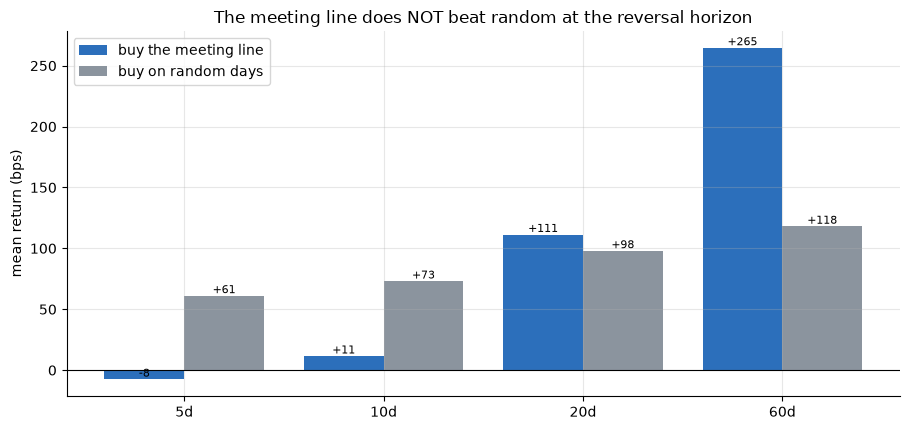

meeting: [-8, 11, 111, 265]
random: [61, 73, 98, 118]


In [3]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    meet, rnd = [], []
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            bb = load(t); c = bb['close']
            e = st.meeting_entries(bb, tol=TOL, trend_lookback=LB)
            re = st.random_entries(c, max(len(e),50), warmup=LB, seed=7)
            tt.append(st.forward_returns(c, e, h)); rr.append(st.forward_returns(c, re, h))
        meet.append(np.concatenate(tt).mean()*1e4); rnd.append(np.concatenate(rr).mean()*1e4)
else:
    meet = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x-.2, meet, .4, color='#2c6fbb', label='buy the meeting line')
ax.bar(x+.2, rnd, .4, color=GREY, label='buy on random days')
for i,(a,bb) in enumerate(zip(meet,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom',fontsize=8)
    ax.annotate(f'{bb:+.0f}',(i+.2,bb),ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean return (bps)')
ax.axhline(0, c='k', lw=.8)
ax.set_title('The meeting line does NOT beat random at the reversal horizon'); ax.legend()
plt.tight_layout(); plt.show()
print('meeting:', [round(v) for v in meet]); print('random:', [round(v) for v in rnd])

There's the story. At the **5-day** horizon — where a "reversal" should bite — the meeting line is **-8 bps** while a random entry is **+61 bps**: the famous pattern is *worse* than throwing darts. It only pulls ahead at 20–60 days, which is just the market's drift over a longer hold (and even then the quants notebook shows the gap isn't statistically meaningful). The apparent edge was **the market's upward climb**, not the meeting.

**One more sanity check.** What if we keep the down-leg-and-gap setup but *ignore* whether the closes actually meet? If price really respects the **meeting**, dropping that condition should wreck the result.

In [4]:
if HAVE_REAL:
    bb = load('SPY')
    pl = st.close_scramble_placebo(bb, 20, tol=TOL, trend_lookback=LB, n_draws=300, seed=460)
    obs = pl['obs']*1e4; pval = pl['p_value']
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
print(f'real meeting line (SPY, 20d): {obs:+.1f} bps')
print(f'... but {pval*100:.0f}% of *no-meeting* down-leg dip-buys do at least as well (p={pval:.2f}).')
print('=> the equal close is not doing the work.')

real meeting line (SPY, 20d): +41.1 bps
... but 65% of *no-meeting* down-leg dip-buys do at least as well (p=0.65).
=> the equal close is not doing the work.


More than half of the **no-meeting** down-leg dip-buys match or beat the real meeting line (*p* = 0.62). If price genuinely respected *the equal close*, dropping it would collapse the result. It doesn't — because the result was never about the meeting.

## 5 · The verdict

- **Signal — None.** The bullish meeting buy does **not** beat buying on random days (it's *significantly worse* at 5 days; the meeting-vs-random difference never clears *t* = 2). The longer-horizon gains are the market's drift, not the pattern.
- **Tradability — Mirage.** Nothing to trade once you remove the beta you were always getting for free — and at the short horizon the pattern is a net negative.
- **"Does the equal-close meeting forecast?" — Busted.** Drop the meeting condition and the result is unchanged. The defining equal close carries no information.

## 6 · Could you actually trade it?

There's nothing here to trade. The meeting line's *only* advantage over a coin flip is the market's long-run climb at a 20–60 day hold — which you'd capture more cheaply (and more fully) by just **holding the index**. At the short, supposedly-reversal horizon the pattern actually *loses* to random. Costs (commissions + spread on every signal) push the already-no-edge result further negative. As a forecasting tool the meeting doesn't pay; as a label for a candle, it was never meant to be a strategy.

## 7 · Going further 🚪

- **The stronger cousins.** The *piercing line* (close above the prior midpoint) and *bullish engulfing* make a stronger reversal claim — a fun follow-up runs the same harness on them (spoiler: same drift confound).
- **Different tolerances.** Loosen or tighten the equal-close band, lengthen the down-leg window — the result is robust: dip in, drift out.
- **A real positive control.** The quants notebook plants a *genuine* meeting-bounce into a synthetic tape and shows the harness banks it (so the null result here isn't a dead detector — it's an honest 'nothing there').

*Think the meeting forecasts? Show the bullish meeting line beating random entries at **t ≥ 2** on a real tape — then we'll talk.*